# Recalculating Coastal Upwelling Transport Index (CUTI), Jacox et al., (2018)

For CUTI we need the Ekman net contribution ($Ek_{int}$) + the geostrophic part ($U_{geo}$)

* For the $Ek_{int}$ we integrate the boundaries at every 1 degree perimeter, let the equations be as follow:

\
\begin{aligned}
Q^{(E)}_{E} &= \int_{y_1}^{y_2} U_E(x_E,y)\,dy, = 0 \\
Q^{(W)}_{E} &= - \int_{y_1}^{y_2} U_E(x_W,y)\,dy, \\
Q^{(N)}_{E} &= \int_{x_W}^{x_E} V_E(x,y_2)\,dx, \\
Q^{(S)}_{E} &= - \int_{x_W}^{x_E} V_E(x,y_1)\,dx, \\
Q_{\mathrm{div}}
&= Q^{(E)}_{E} + Q^{(W)}_{E} + Q^{(N)}_{E} + Q^{(S)}_{E}
= \iint\limits_{A} \nabla \!\cdot\! \mathbf{M}_E \, dA, \\
\bar{w}_E
&= \frac{Q_{\mathrm{div}}}{A}
= \frac{1}{\rho\,f}\, \bigl(\nabla \times \boldsymbol{\tau}\bigr)_z .
\end{aligned}

* For geostrophic transport ($U_{geo}$), $\Delta \mathrm{SSH}$ is the difference between the coastal SSH values at the northernmost and southernmost grid points within the 1° segment. The $MLD$ is defined as the width of the Rossby radius of deformation (30 km; R1).

$$
\begin{aligned}
u_{\mathrm{geo}} &= \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}, \\[1ex]
\mathbf{U}_{\mathrm{geo}} &= \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}, \\[1ex]
\text{CUTI} &= U_{\text{ek}} + U_{\text{geo}} \\
&= \frac{\nabla \tau}{\rho_w f} \cdot \hat{k} - \frac{gD}{f} \frac{\partial \eta}{\partial y}.
\end{aligned}
$$

where $g$ is the gravitational acceleration, $D$ is the Ekman layer depth, and $d$ is distance to the coast.

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm 

## Functions

In [2]:
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge
    in the cross-shore (lon) direction only.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    # Dilate only in the lon (cross-shore) direction
    cross_shore_kernel = np.array([[0, 0, 0],
                                   [1, 1, 1],
                                   [0, 0, 0]])

    band = binary_dilation(coast, structure=cross_shore_kernel, iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
def lat_band_mean(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute the mean of f for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        Mean of f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        results.append(f_band.mean(dim='lat'))
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))

    return f_out

In [4]:
## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Data

In [5]:
ds = xr.open_dataset('winds_and_components.nc')
ds

<xarray.Dataset> Size: 8GB
Dimensions:            (lon: 602, lat: 542, time: 432)
Coordinates:
  * lon                (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat                (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.951 10.03
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 1GB ...
    v10                (time, lat, lon) float64 1GB ...
    tau_alongshore     (time, lat, lon) float64 1GB ...
    Uekman_Crossshore  (time, lat, lon) float64 1GB ...
    Inshore_Uekman     (time, lat, lon) float64 1GB ...
    Uek_geo            (time, lat, lon) float64 1GB ...
    Vek_geo            (time, lat, lon) float64 1GB ...
    f                  (lat) float64 4kB ...

## Uekman or $Ek_{int}$ calculation
* We are using the non-rotated geographical Uekman_geo and Vekman_geo

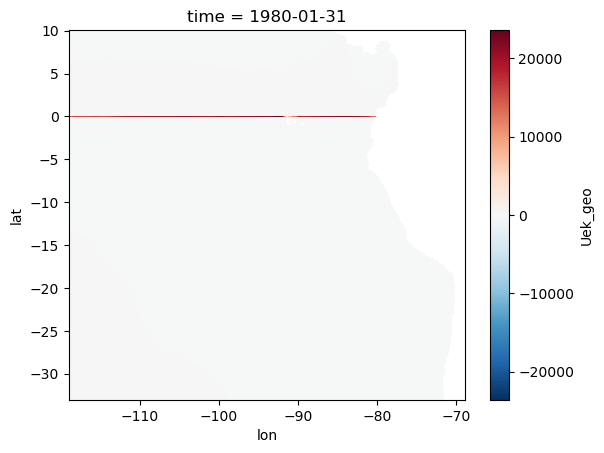

In [6]:
ds.Uek_geo.isel(time=0).plot()

In [7]:
## 111km mask or (1/12)*10*111 km
mask = coastal_band_mask(ds, var='Uek_geo', iterations=10)

wind_coastal = ds.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4)) 
wind_coastal

<xarray.Dataset> Size: 925MB
Dimensions:            (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon                (lon) float64 2kB -84.95 -84.87 -84.78 ... -68.95 -68.87
  * lat                (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.162 -4.079
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 132MB nan nan nan ... nan nan
    v10                (time, lat, lon) float64 132MB nan nan nan ... nan nan
    tau_alongshore     (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Uekman_Crossshore  (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Inshore_Uekman     (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Uek_geo            (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Vek_geo            (time, lat, lon) float64 132MB nan nan nan ... nan nan
    f                  (lat, lon) float64 306kB nan nan nan nan ... nan nan nan

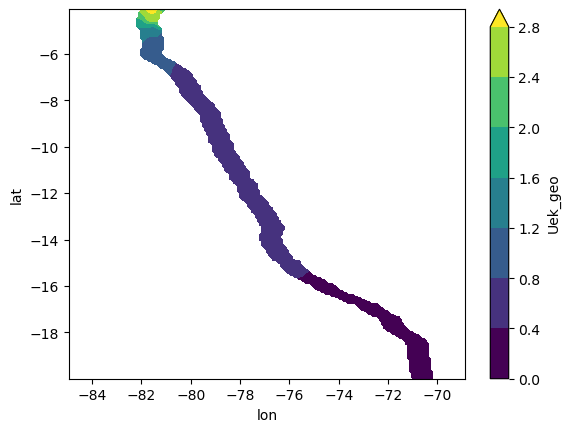

In [8]:
wind_coastal.Uek_geo.std('time').plot.contourf(robust=True)

In [9]:
wind_coastal.lat

<xarray.DataArray 'lat' (lat: 197)> Size: 2kB
array([-19.994865, -19.916554, -19.838205, -19.759817, -19.681391, -19.602926,
       -19.524422, -19.445881, -19.367301, -19.288683, -19.210028, -19.131335,
       -19.052604, -18.973836, -18.89503 , -18.816187, -18.737307, -18.658391,
       -18.579437, -18.500447, -18.42142 , -18.342357, -18.263257, -18.184122,
       -18.10495 , -18.025743, -17.9465  , -17.867221, -17.787907, -17.708557,
       -17.629173, -17.549753, -17.470298, -17.390809, -17.311285, -17.231727,
       -17.152134, -17.072507, -16.992845, -16.91315 , -16.833421, -16.753659,
       -16.673863, -16.594033, -16.514171, -16.434275, -16.354346, -16.274384,
       -16.19439 , -16.114364, -16.034304, -15.954213, -15.87409 , -15.793934,
       -15.713747, -15.633528, -15.553278, -15.472996, -15.392683, -15.312339,
       -15.231964, -15.151558, -15.071121, -14.990654, -14.910157, -14.829629,
       -14.749072, -14.668484, -14.587867, -14.50722 , -14.426544, -14.345838,
       -14.265103, -14.18434 , -14.103547, -14.022725, -13.941875, -13.860997,
       -13.78009 , -13.699156, -13.618193, -13.537202, -13.456184, -13.375139,
       -13.294066, -13.212965, -13.131838, -13.050684, -12.969503, -12.888295,
       -12.807062, -12.725801, -12.644515, -12.563203, -12.481865, -12.400501,
       -12.319112, -12.237697, -12.156258, -12.074793, -11.993303, -11.911789,
       -11.83025 , -11.748687, -11.667099, -11.585488, -11.503852, -11.422193,
       -11.34051 , -11.258804, -11.177074, -11.095321, -11.013546, -10.931747,
       -10.849926, -10.768082, -10.686216, -10.604328, -10.522418, -10.440486,
       -10.358533, -10.276557, -10.194561, -10.112543, -10.030505,  -9.948445,
        -9.866365,  -9.784264,  -9.702143,  -9.620001,  -9.53784 ,  -9.455658,
        -9.373457,  -9.291237,  -9.208997,  -9.126737,  -9.044459,  -8.962162,
        -8.879846,  -8.797511,  -8.715158,  -8.632787,  -8.550398,  -8.467991,
        -8.385566,  -8.303124,  -8.220664,  -8.138187,  -8.055693,  -7.973182,
        -7.890654,  -7.808109,  -7.725549,  -7.642972,  -7.560379,  -7.47777 ,
        -7.395145,  -7.312505,  -7.22985 ,  -7.147179,  -7.064493,  -6.981792,
        -6.899077,  -6.816347,  -6.733603,  -6.650844,  -6.568072,  -6.485285,
        -6.402485,  -6.319671,  -6.236845,  -6.154004,  -6.071151,  -5.988285,
        -5.905407,  -5.822516,  -5.739612,  -5.656697,  -5.573769,  -5.49083 ,
        -5.407879,  -5.324916,  -5.241943,  -5.158958,  -5.075962,  -4.992956,
        -4.909939,  -4.826911,  -4.743873,  -4.660825,  -4.577768,  -4.4947  ,
        -4.411623,  -4.328537,  -4.245441,  -4.162336,  -4.079223])
Coordinates:
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079

(194,)
(194,)


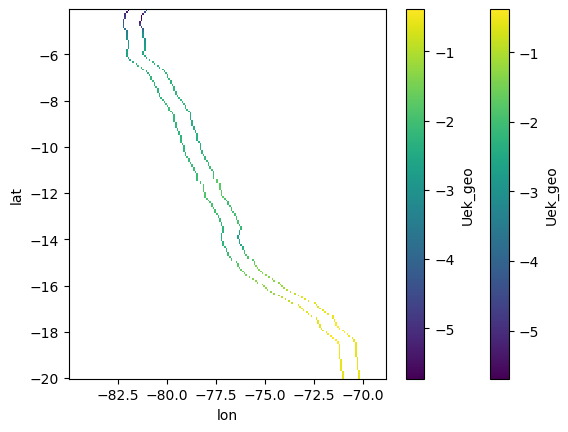

In [10]:
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
lon_in = wind_coastal.Uek_geo.where(coast_mask)

valid_w = valid.shift(lon=+1).fillna(False).astype(bool)
offshore_mask = valid & (~valid_w)
lon_out = wind_coastal.Uek_geo.where(offshore_mask)

lon_west = lon_out.lon.values
lon_east = lon_in.lon.values

print(lon_west.shape)
print(lon_east.shape)

lon_out.mean(dim=('time')).plot()
lon_in.mean(dim=('time')).plot()

In [11]:
# Coast (east edge): longitude of the easternmost valid cell per lat
# lon_east_vals = lon_in.mean('time').max('lon')   # wrong — this gives the max value, not the lon position

# Better: find the lon where the cell is valid
coast_lons = []
offshore_lons = []

for j in tqdm(range(len(wind_coastal.lat))):
    # East (coast)
    row_e = lon_in.mean('time').isel(lat=j).values
    cols_e = np.where(np.isfinite(row_e))[0]
    coast_lons.append(wind_coastal.lon.values[cols_e[0]] if len(cols_e) > 0 else np.nan)
    
    # West (offshore)
    row_w = lon_out.mean('time').isel(lat=j).values
    cols_w = np.where(np.isfinite(row_w))[0]
    offshore_lons.append(wind_coastal.lon.values[cols_w[0]] if len(cols_w) > 0 else np.nan)

coast_lons = np.array(coast_lons)
offshore_lons = np.array(offshore_lons)

100%|██████████████████████████████████████████████████████████████████████████████████| 197/197 [00:29<00:00,  6.71it/s]


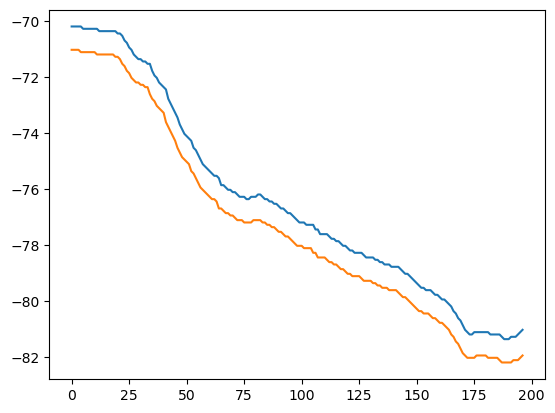

In [12]:
import matplotlib.pyplot as plt

plt.plot(coast_lons)
plt.plot(offshore_lons)
# plt.plot(lon_east)

### Now the $Ek_{int}$

In [13]:
def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,
                  offshore_lons, coast_lons, all_lats):

    A = 6371000.0

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north))

    lat_vals = Uek_.lat.values
    lon_vals = Uek_.lon.values
    mean_lat = np.mean(lat_vals)

    # Build a 2D mask that follows the coast/offshore boundaries per row
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    strip_mask = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)
    cross_widths = []

    for j, idx in enumerate(band_idx):
        if j >= len(lat_vals):
            break
        lw = offshore_lons[idx]
        le = coast_lons[idx]
        if np.isfinite(lw) and np.isfinite(le):
            strip_mask[j, :] = (lon_vals >= lw) & (lon_vals <= le)
            width = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(np.abs(le - lw))
            cross_widths.append(width)

    total_dx = np.mean(cross_widths) if cross_widths else 101750.0

    # Apply strip mask
    strip_da = xr.DataArray(strip_mask, dims=('lat', 'lon'),
                            coords={'lat': lat_vals, 'lon': lon_vals})
    Uek_ = Uek_.where(strip_da)
    Vek_ = Vek_.where(strip_da)

    # Grid spacing
    dy_mean = A * np.deg2rad(np.abs(np.diff(lat_vals))).mean()
    dx_mean = A * np.cos(np.deg2rad(mean_lat)) * np.deg2rad(np.abs(np.diff(lon_vals))).mean()

    # Boundary detection
    valid_da = xr.where(np.isfinite(Uek_), 1, 0)
    valid_e = valid_da.shift(lon=-1)
    valid_w = valid_da.shift(lon=+1)
    west_mask = (valid_da == 1) & (valid_w == 0)
    east_mask = (valid_da == 1) & (valid_e == 0)

    easternmost  = Uek_.where(east_mask)
    westernmost  = Uek_.where(west_mask)
    southernmost = Vek_.isel(lat=0)
    northernmost = Vek_.isel(lat=-1)

    QE = (easternmost.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * dy_mean)
    QW = -(westernmost.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * dy_mean)
    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * dx_mean)
    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * dx_mean)

    Qdiv = (QW + QS + QN) / total_dx

    return Qdiv, total_dx

In [14]:
# ============================================================
# Compute boundary longitudes from the mask
# ============================================================
valid = np.isfinite(wind_coastal.Uek_geo.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lon_in = wind_coastal.Uek_geo.where(coast_mask)
lon_out = wind_coastal.Uek_geo.where(offshore_mask)

lat_all = wind_coastal.lat.values
lon_all = wind_coastal.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    # Coast (east edge)
    row_e = coast_mask.isel(lat=j).values
    cols_e = np.where(row_e)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]

    # Offshore (west edge)
    row_w = offshore_mask.isel(lat=j).values
    cols_w = np.where(row_w)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

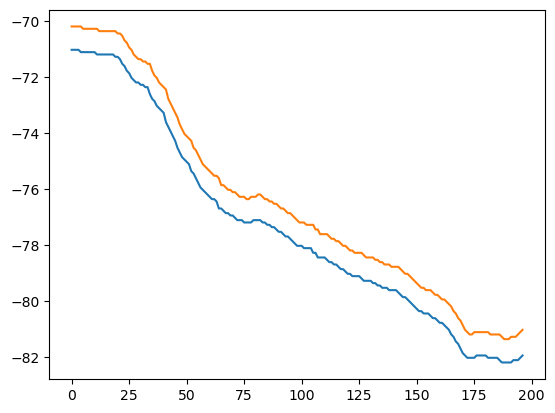

In [15]:
plt.plot(offshore_lons)
plt.plot(coast_lons)

In [16]:
# ============================================================
# Loop over latitude bands
# ============================================================
lat_top_start = -4
lat_top_end   = -17

results = []
lat_band_centers = []
total_dx_list = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    Qdiv_band, tdx = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        offshore_lons=offshore_lons, coast_lons=coast_lons,
        all_lats=lat_all,
    )
    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    total_dx_list.append(tdx)

Qdiv_all = xr.concat(results, dim='lat_band')
U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)

100%|████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 23.61it/s]


In [17]:
# This should show ~100 km difference per row
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        diff = np.abs(coast_lons[j] - offshore_lons[j])
        # if diff > 1.5:  # more than ~1.5 degrees = ~150 km
        print(f"lat={lat_all[j]:.1f}: coast={coast_lons[j]:.2f}, offshore={offshore_lons[j]:.2f}, diff={diff:.2f}°")

lat=-20.0: coast=-70.20, offshore=-71.03, diff=0.83°
lat=-19.9: coast=-70.20, offshore=-71.03, diff=0.83°
lat=-19.8: coast=-70.20, offshore=-71.03, diff=0.83°
lat=-19.8: coast=-70.20, offshore=-71.03, diff=0.83°
lat=-19.7: coast=-70.20, offshore=-71.12, diff=0.92°
lat=-19.6: coast=-70.28, offshore=-71.12, diff=0.83°
lat=-19.5: coast=-70.28, offshore=-71.12, diff=0.83°
lat=-19.4: coast=-70.28, offshore=-71.12, diff=0.83°
lat=-19.4: coast=-70.28, offshore=-71.12, diff=0.83°
lat=-19.3: coast=-70.28, offshore=-71.12, diff=0.83°
lat=-19.2: coast=-70.28, offshore=-71.12, diff=0.83°
lat=-19.1: coast=-70.28, offshore=-71.20, diff=0.92°
lat=-19.1: coast=-70.37, offshore=-71.20, diff=0.83°
lat=-19.0: coast=-70.37, offshore=-71.20, diff=0.83°
lat=-18.9: coast=-70.37, offshore=-71.20, diff=0.83°
lat=-18.8: coast=-70.37, offshore=-71.20, diff=0.83°
lat=-18.7: coast=-70.37, offshore=-71.20, diff=0.83°
lat=-18.7: coast=-70.37, offshore=-71.20, diff=0.83°
lat=-18.6: coast=-70.37, offshore=-71.20, diff

In [18]:
total_dx = total_dx_list
total_dx

[96990.08890757518,
 93766.7349672885,
 103569.72966042564,
 97988.68412124248,
 96988.78548028522,
 95199.2916317971,
 95670.36436999508,
 95690.1709494223,
 96487.9994613219,
 94609.3177390422,
 96603.57056482328,
 101184.9840581519,
 105240.05346775087]

In [19]:
U_ek

<xarray.DataArray (lat_band: 13, time: 432)> Size: 45kB
array([[2.02300758, 1.08936856, 0.72499953, ..., 3.49045862, 4.13789148,
        3.18237497],
       [2.32402782, 1.35202129, 1.02793617, ..., 4.81747569, 5.02166677,
        4.27961973],
       [1.88049646, 1.38230123, 1.34971995, ..., 3.93990381, 3.92728582,
        3.45621628],
       ...,
       [1.6280136 , 1.51085192, 1.49118777, ..., 2.89953397, 2.78383907,
        2.5515079 ],
       [1.40027101, 1.20750694, 1.01900718, ..., 1.9986658 , 2.02714466,
        1.69293805],
       [1.27511479, 0.9268969 , 0.84125679, ..., 1.97048396, 1.89923512,
        1.73652459]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

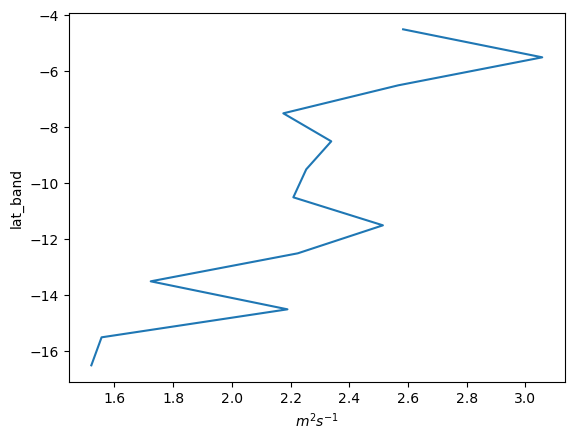

In [20]:
# (U_ek).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
(U_ek).sel(lat_band=slice(-4,-17)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')

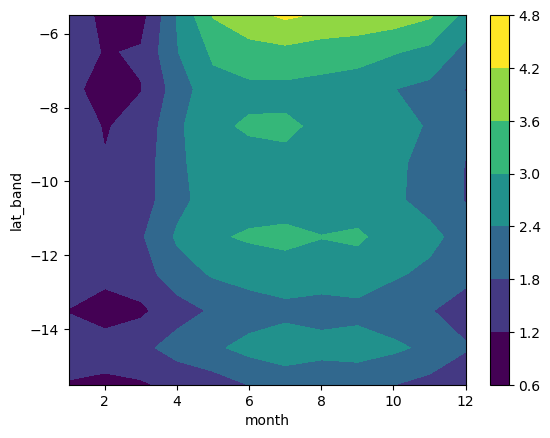

In [21]:
seasonality(U_ek).sel(lat_band=slice(-5,-16)).plot.contourf(x='month')

* the box-integration approach used in CUTI cannot capture localized upwelling cells driven by fine-scale wind stress curl and coastline geometry in the NHUS.

But Jacox said: "Integration around the region of interest eliminates the need for estimating the coastline orientation, ensures that Ekman transport/pumping associated with alongshore and cross-shore variations in the wind are captured, and enables more accurate closure of the transport budget."

If strong upwelling at 14.5°S is partially cancelled by weaker upwelling or even downwelling elsewhere within the same 1° band, the box-integrated value gets diluted.

upwelling cell at 14°S–15°S is a nearshore feature — it's concentrated within the first ~10–20 km of the coast, likely driven by the local coastline geometry and wind stress curl in the orographic shadow. When you average over a wider strip, the offshore portion (where upwelling is weaker or absent) dilutes the signal.

The sensitivity of the CUTI Ekman component to the cross-shore integration width reveals that the upwelling intensification near 14°S–15°S is a nearshore feature confined within approximately 10 km of the coast. This localized cell is smoothed out when integrating over the standard ~100 km coastal strip, suggesting that the optimal integration width for CUTI in the NHUS may be narrower than in the CCS (75 km, 30km for MLD), consistent with the thinner shelf at these latitudes (14-15, 50-60km), thus the shelf geometry is a relevant factor.

The upwelling intensification at 14°S–15°S is a nearshore feature confined to the narrow continental shelf (~10–20 km), which is not fully resolved when CUTI integrates over a broader coastal strip. This highlights the sensitivity of box-integrated indices to the cross-shore integration width, particularly in regions where the shelf is narrow relative to the standard integration distance.


In [22]:
A = 6371000.0
lat_top_start = -4
lat_top_end   = -17

d_coast_list = []
lat_band_centers = []

for lat_north in range(lat_top_start, lat_top_end, -1):
    lat_south = lat_north - 1
    lat_s = lon_in.sel(lat=slice(lat_south, lat_north)).lat.values[0]
    lat_n = lon_in.sel(lat=slice(lat_south, lat_north)).lat.values[-1]
    d = A * np.deg2rad(np.abs(lat_n - lat_s))
    d_coast_list.append(d)
    lat_band_centers.append(0.5 * (lat_south + lat_north))

d_coast = xr.DataArray(
    d_coast_list,
    dims='lat_band',
    coords={'lat_band': lat_band_centers},
)

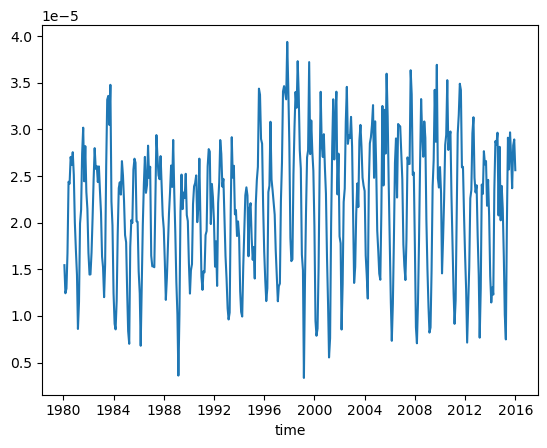

In [23]:

((U_ek/d_coast).mean(dim='lat_band')).plot()
# ((U_ek.sel(lat_band=slice(-5,-16))).mean(dim='lat_band')).plot()

In [24]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

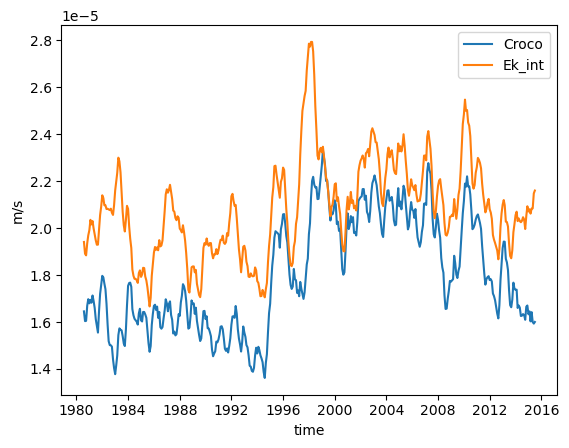

In [25]:
import matplotlib.pyplot as plt

wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13,center=True).mean().rename('m/s').plot(label='Croco')
(((U_ek)).mean(dim='lat_band')/d).rolling(time=13,center=True).mean().rename('m/s').plot(label='Ek_int')
plt.legend()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [26]:
ssh = xr.open_dataset('SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

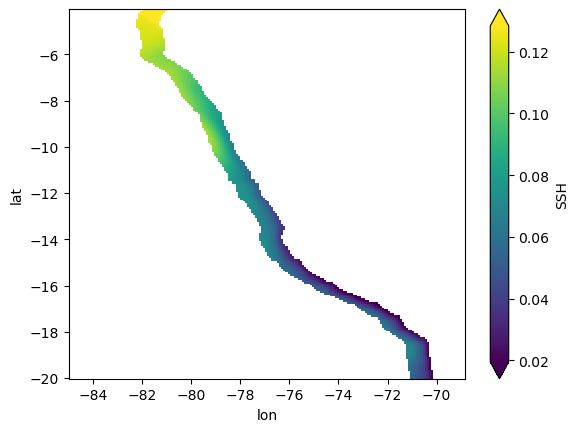

In [27]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4))
ssh.mean('time').SSH.plot(robust=True)

In [28]:
valid = np.isfinite(ssh.SSH.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
ssh_coast = ssh.SSH.where(coast_mask)

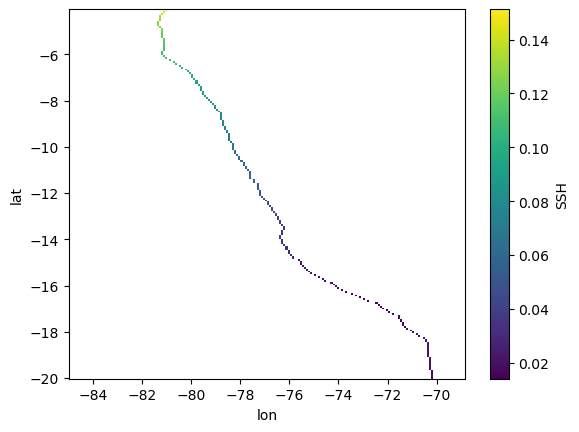

In [29]:
ssh_coast.mean('time').plot()

In [30]:
## Extract SSH at the coastline only (easternmost valid cell per row)
A = 6371000.0

lat_top_start = -4
lat_top_end   = -17

delta_SSH = []
d_coast_list = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    SSH_band = ssh_coast.mean('lon').sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.isel(lat=0)
    northernmost = SSH_band.isel(lat=-1)

    delta_SSH.append(northernmost - southernmost)

    # Actual distance between south and north coastal points
    lat_s = SSH_band.lat.values[0]
    lat_n = SSH_band.lat.values[-1]
    d = A * np.deg2rad(np.abs(lat_n - lat_s))
    d_coast_list.append(d)

ssh_ = xr.concat(delta_SSH, dim='lat_band')
ssh_ = ssh_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

d_coast = xr.DataArray(d_coast_list, dims='lat_band',
                        coords={'lat_band': ssh_.lat_band})

# Verify: should be positive on average (SSH increases northward along coast)
print("Mean ssh_ (should be positive):", ssh_.mean().values)

100%|████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 16.73it/s]

Mean ssh_ (should be positive): 0.009845316


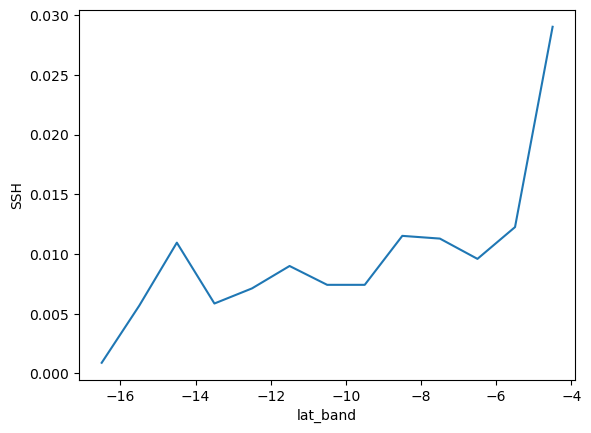

In [31]:
ssh_.mean('time').plot()

In [32]:
lat_centers = np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
Omega = 7.2921e-5
f_ = 2 * Omega * np.sin(np.deg2rad(lat_centers))
f_ = xr.DataArray(f_, dims='lat_band', coords={'lat_band': lat_centers})
f_

<xarray.DataArray (lat_band: 13)> Size: 104B
array([-1.14426314e-05, -1.39783362e-05, -1.65097831e-05, -1.90362009e-05,
       -2.15568201e-05, -2.40708729e-05, -2.65775935e-05, -2.90762183e-05,
       -3.15659862e-05, -3.40461388e-05, -3.65159206e-05, -3.89745792e-05,
       -4.14213659e-05])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [33]:
# d_coast = (1/12)*10*111*1000  # 1 degree of latitude in meters
g = 9.81

# Geostrophic cross-shore velocity from alongshore SSH gradient at the coast.
# u_geo = (g/f) * (dSSH/dy)
# Sign convention for CUTI divergence framework:
#   In SH (f<0), with SSH increasing northward (ssh_>0):
#     u_geo = (g / f_neg) * (positive) = negative → onshore (convergent)
#   This is correct: onshore geostrophic return flow reduces CUTI below U_ek.
u_geo = (g / f_) * (ssh_ / d_coast)

# Verify: should be negative on average (onshore)
print("Mean u_geo (should be negative):", u_geo.mean().values)

Mean u_geo (should be negative): -0.05106895862698817


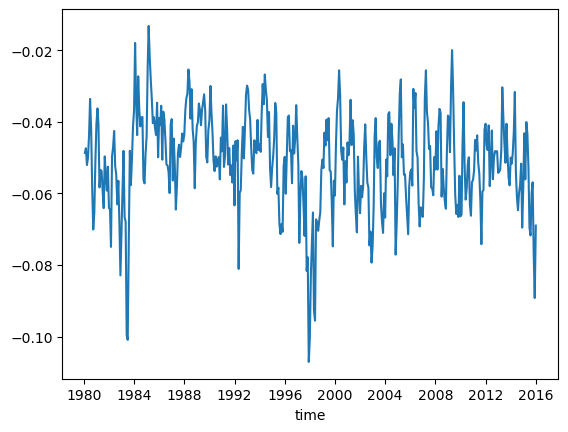

In [34]:
u_geo.mean(dim=('lat_band')).plot()

* The onshore geostrophic flow increased during EN 1997-98

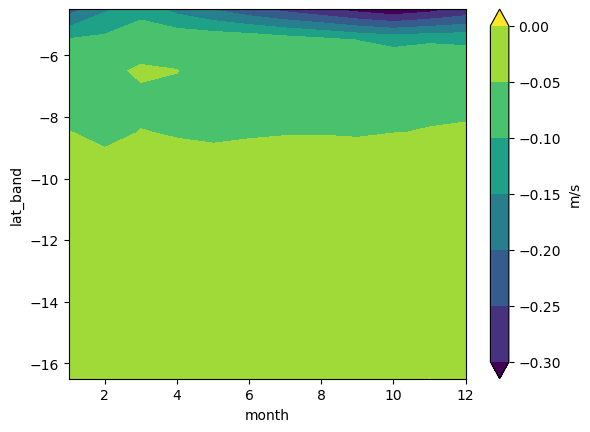

In [35]:
seasonality(u_geo.rename('m/s')).plot.contourf(robust=True)

### MLD

In [36]:
MLD_ds = xr.open_dataset('MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [37]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', iterations=3)
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-20,-4))
MLD_ds

<xarray.Dataset> Size: 132MB
Dimensions:  (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 132MB nan nan nan nan ... nan nan nan nan

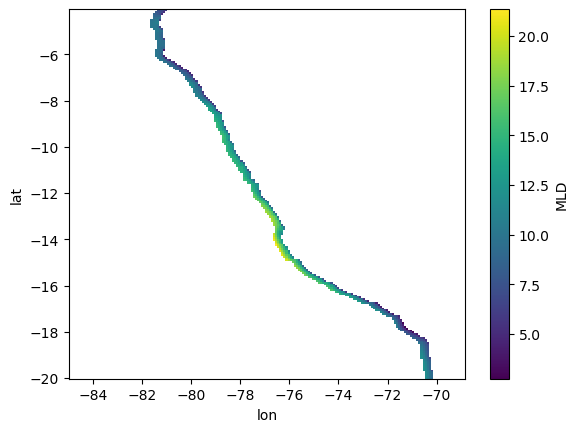

In [38]:
MLD_ds.MLD.std('time').plot()

In [39]:
delta_mld = []

lat_top_start = -4   # first northern edge
lat_top_end   = -17  # last northern edge

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    mld_band = MLD_ds.MLD.sel(lat=slice(lat_south, lat_north)).mean(dim='lat')
    delta_mld.append(mld_band)

mld_ = xr.concat(delta_mld, dim='lat_band')
mld_ = mld_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 196.37it/s]


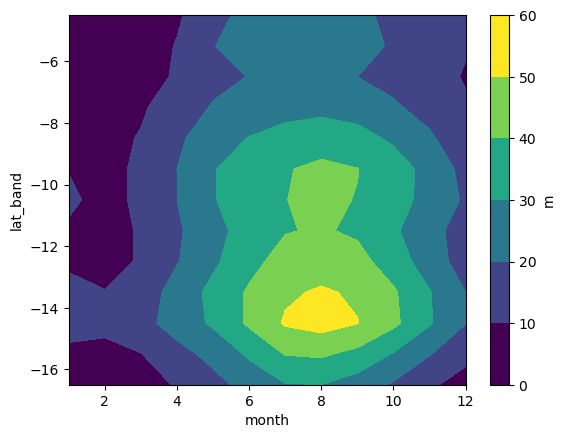

In [40]:
seasonality(mld_.mean(dim=('lon')).rename('m')).plot.contourf()

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

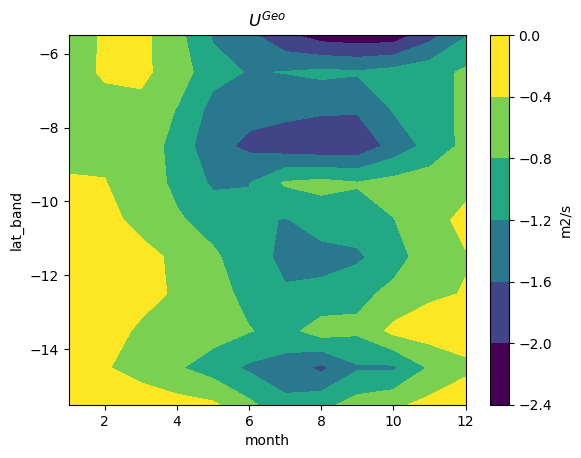

In [41]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(robust=True)
# seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)

plt.title('$U^{Geo}$')

* Negative is onshore 

In [42]:
U_geo.sel(lat_band=slice(-5.5,-16.5))

<xarray.DataArray (lat_band: 12, time: 432, lon: 194)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

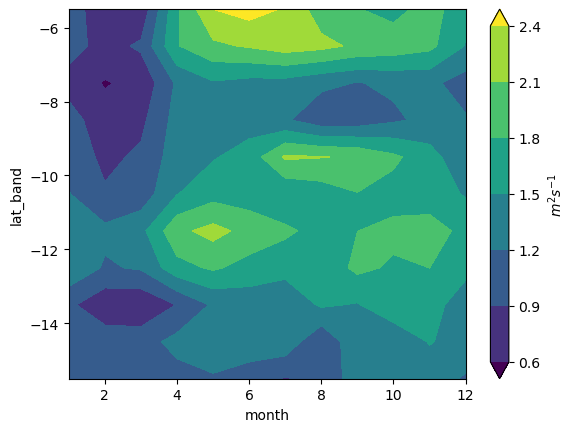

In [43]:
CUTI = (U_ek) + (U_geo)#m2/s

seasonality((CUTI).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(robust=True)

Text(0.5, 1.0, '$CUTI$')

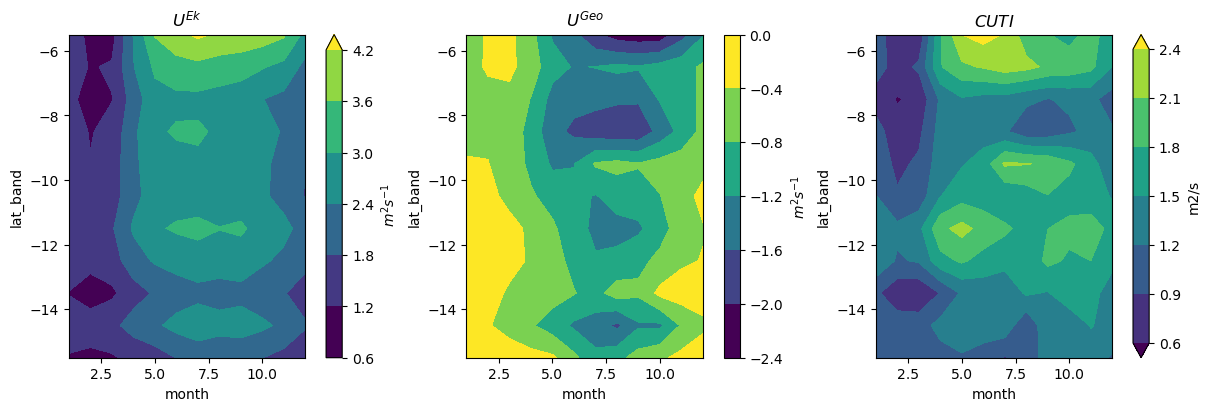

In [44]:
fig,ax = plt.subplots(1,3,figsize=(12,4),constrained_layout=True)

seasonality(U_ek).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[0])
seasonality(U_geo).mean(dim='lon').sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[1])
seasonality((CUTI).mean(dim='lon')).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(
    x='month',robust=True,ax=ax[2])

ax[0].set_title('$U^{Ek}$')
ax[1].set_title('$U^{Geo}$')
ax[2].set_title('$CUTI$')

* CUTI doesn't work because of the north of Peru having a positive Ugeostrophic velocity 

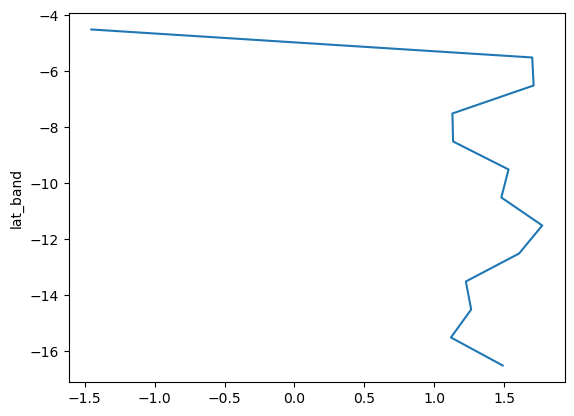

In [45]:
# (CUTI).mean(dim=('lon','time')).sel(lat_band=slice(-5,-16.5)).plot(y='lat_band')
(CUTI).mean(dim=('lon','time')).plot(y='lat_band')

In [46]:
wmld2 = xr.open_dataset('W_mld_Croco.nc').compute()
wmld2 = wmld2.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld2

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [47]:
wmld_ = lat_band_mean(wmld2.WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 204.70it/s]


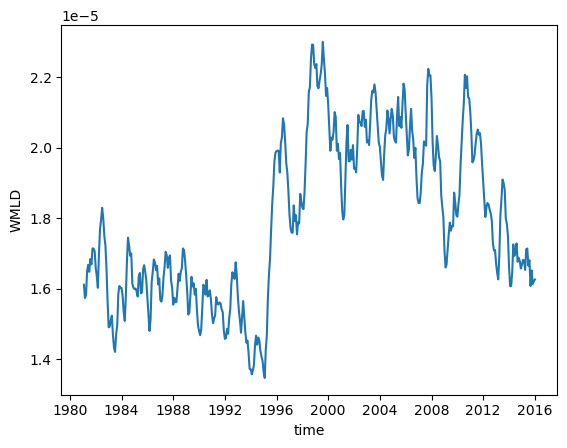

In [48]:
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot()

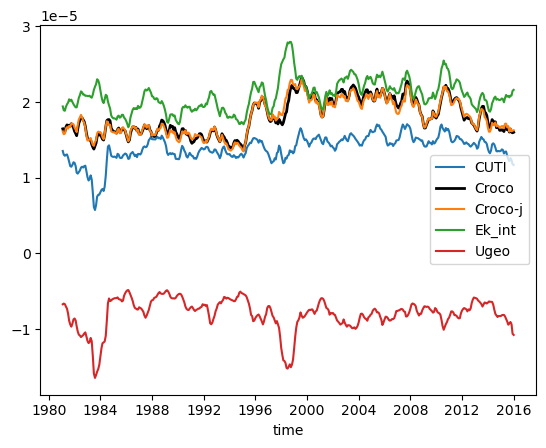

In [49]:


(CUTI/d_coast).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(label='Croco-j')

(((U_ek)).mean(dim='lat_band')/d).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
(U_geo/d_coast).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')

plt.legend()

### Seasonality

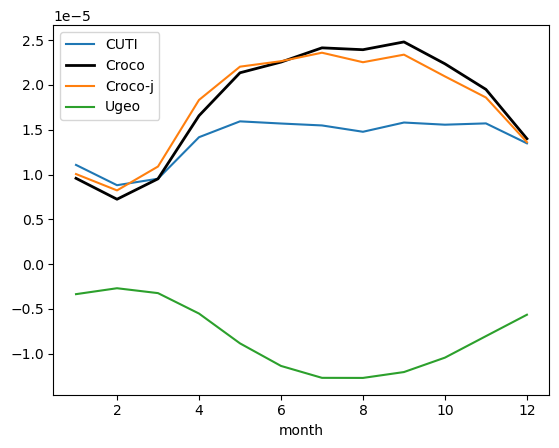

In [50]:
seasonality((CUTI/d_coast)).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).plot(label='CUTI')
seasonality(wmld.mean(dim=('lon','lat')).WMLD).rename('m/s').plot(label='Croco',linewidth=2,color='black')
seasonality(wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band'))).rename('m/s').plot(label='Croco-j')

# (((U_ek)).mean(dim='lat_band')/d).rename('m/s').plot(label='Ek_int')
seasonality((U_geo/d_coast).mean(dim=('lat_band','lon'))).plot(label='Ugeo')
# seasonality((ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat'))).plot(label='Uekman_crosshore')

plt.legend()

* Capture doesn't capture mesoescale features because of how is the ugeostrophic velocity built

Text(0.5, 1.0, 'CUTI')

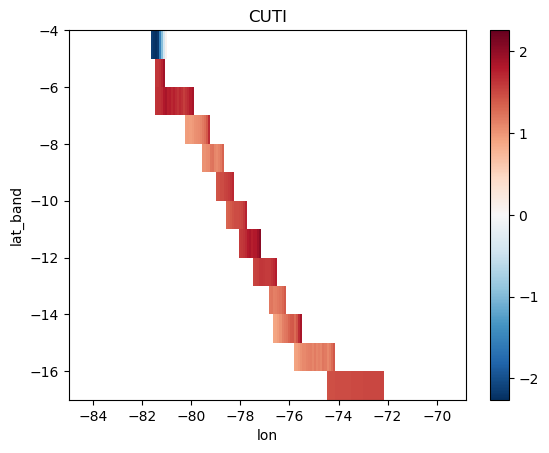

In [51]:
CUTI.mean('time').plot()
plt.title('CUTI')

In [52]:
nitrogen = xr.open_dataset('Nitrogen.nc').compute()
nitrogen

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 564MB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0
    TN_mld   (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0

In [53]:
N = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-17,-4))
N

<xarray.Dataset> Size: 160MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 53MB nan nan nan nan ... nan nan nan nan
    TN_mld   (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [54]:
N_ = lat_band_mean(N.TN_mld,
    lat_top_start=-4,
    lat_top_end=-17,
)
N_

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 200.63it/s]


<xarray.DataArray 'TN_mld' (lat_band: 13, time: 432, lon: 194)> Size: 9MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

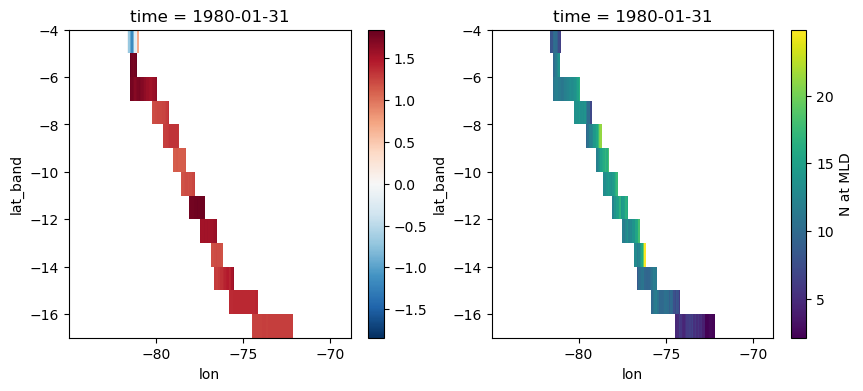

In [55]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
CUTI.isel(time=0).plot(ax=ax[0])
N_.rename('N at MLD').isel(time=0).plot(ax=ax[1])

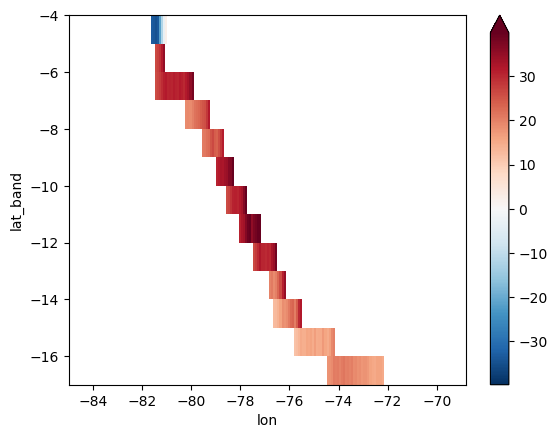

In [56]:
BEUTI = (N_ * CUTI)
(BEUTI).mean('time').plot(robust=True)

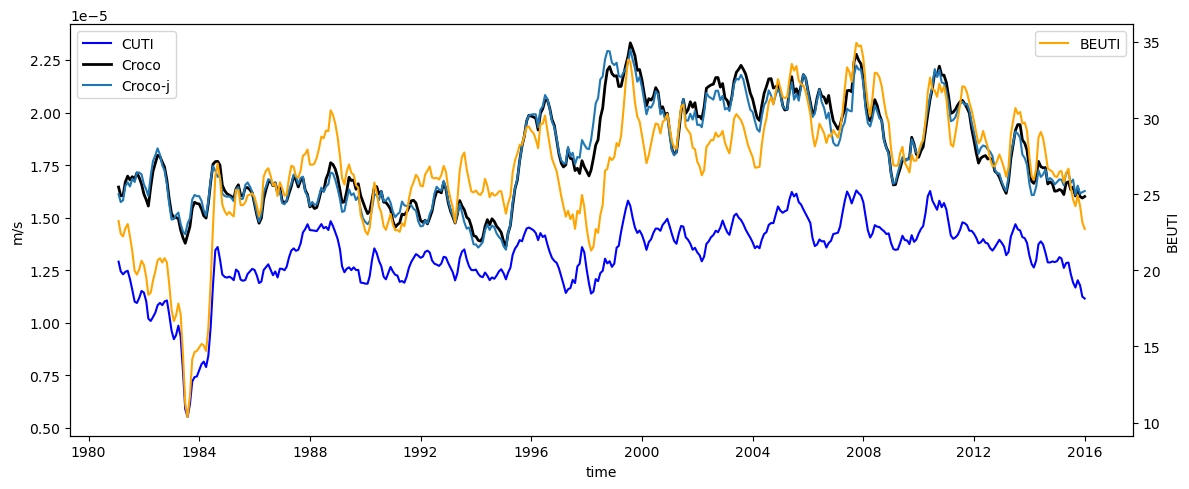

In [57]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis
(CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(ax=ax1, label='CUTI', color='Blue')
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(ax=ax1, label='Croco-j')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

# Right axis for BEUTI
ax2 = ax1.twinx()
BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

plt.tight_layout()

In [58]:
N2 = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-16,-5))

Text(0.5, 1.0, 'Nitrogen Cycle')

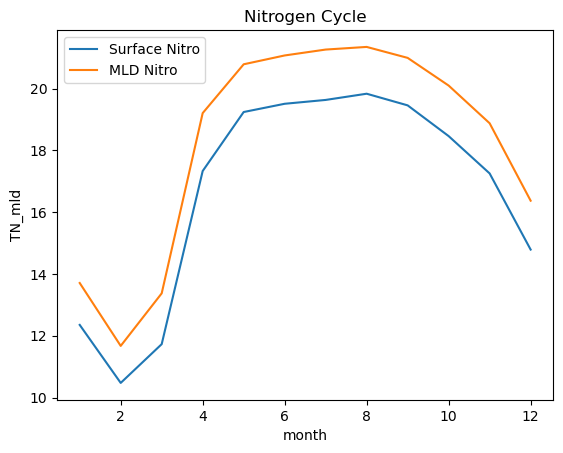

In [59]:
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(label='MLD Nitro')
plt.legend()
plt.title('Nitrogen Cycle')

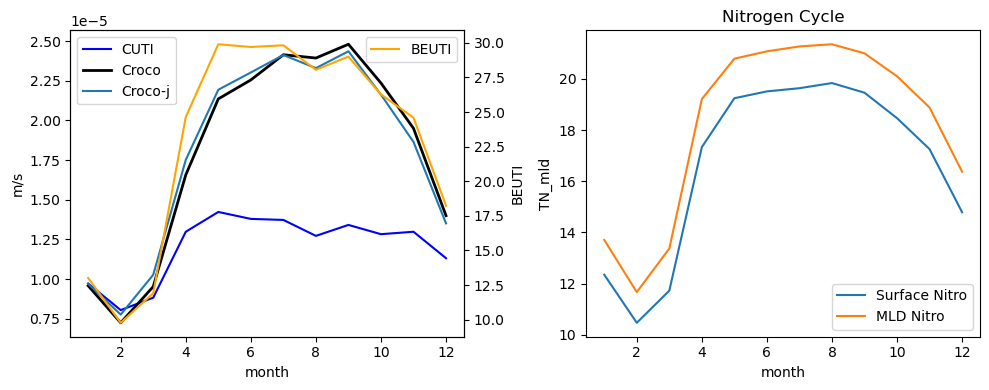

In [60]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# --- Top panel ---
seasonality((CUTI/d).mean(dim=('lon','lat_band'))).plot(ax=ax1, label='CUTI', color='blue')
seasonality(wmld.mean(dim=('lon','lat')).WMLD).rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
seasonality(wmld_.mean(dim=('lon','lat_band'))).rename('m/s').plot(ax=ax1, label='Croco-j')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
seasonality(BEUTI.mean(dim=('lat_band','lon'))).plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

# --- Bottom panel ---
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(ax=ax3, label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(ax=ax3, label='MLD Nitro')
ax3.legend()
ax3.set_title('Nitrogen Cycle')

plt.tight_layout()

* Nitrogen input follows the upwelling season, BEUTI amplifies CUTI in seasonal scales

In [61]:
wmld_ = wmld_.rename('Croco_j')
wmld_

<xarray.DataArray 'Croco_j' (lat_band: 13, time: 432, lon: 194)> Size: 9MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [62]:
CUTI = CUTI.to_dataset(name='CUTI')
# CUTI

In [63]:
CUTI['BEUTI'] = BEUTI
CUTI['UGEO'] = U_geo
CUTI['u_geo'] = u_geo
CUTI['U_ek'] = U_ek
CUTI['N_mld'] = N_
CUTI['CROCO_j'] = wmld_

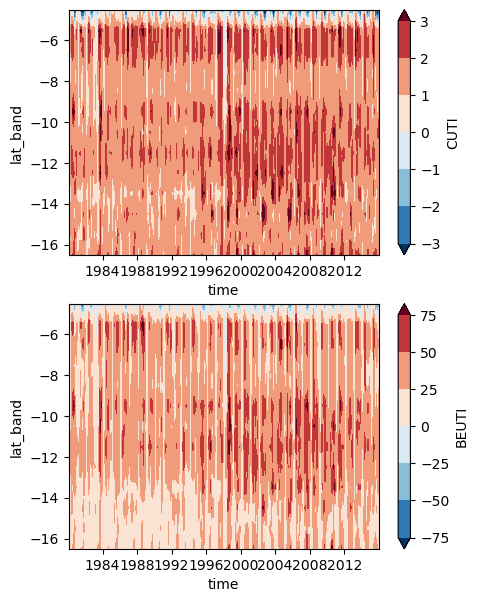

In [64]:
fig,ax = plt.subplots(2,1,figsize=(5,7))
CUTI.CUTI.mean(dim='lon').plot.contourf(robust=True,ax=ax[0])
CUTI.BEUTI.mean(dim='lon').plot.contourf(robust=True,ax=ax[1])

In [65]:
# CUTI.to_netcdf('latitudinal/CUTI_BEUTI_components.nc')

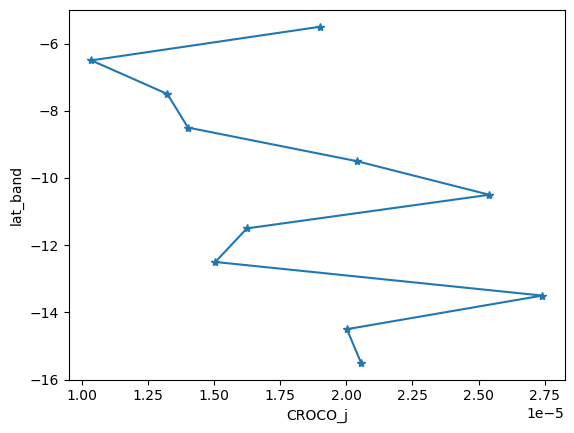

In [66]:
CUTI.CROCO_j.mean(dim=('time','lon')).sel(lat_band=slice(-5,-16)).plot(y='lat_band',marker='*')


In [67]:
UGEO.mean(dim=('lon','time')).plot(y='lat_band',label='$U^{Geo}$')
CUTI.mean(dim=('lon','time')).plot(y='lat_band',label='$CUTI$')
xr.open_dataset('CUTI_BEUTI_components.nc').U_ek.compute().mean(dim=('time')).plot(y='lat_band',label='$U^{Ek}$')
plt.legend()
plt.grid(True)

NameError: name 'UGEO' is not defined